<center><span style="color:#27A3F5;font-size:26px;font-weight:700">Rent price prediction in Berlin</span></center>

<span style="color:#609926;font-size:20px;font-weight:500">Further Exploratory Data Analysis</span>

<span style="font-weight:500">
This notebook performs a second cleaning pass and produces the true final dataset
</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/rent_listings.csv')
df.shape

(15621, 24)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   listing_url           15621 non-null  object 
 1   cold_rent             15621 non-null  float64
 2   area                  15621 non-null  float64
 3   rooms                 15621 non-null  float64
 4   floor                 13673 non-null  float64
 5   free_from             15621 non-null  object 
 6   has_balkon            15621 non-null  bool   
 7   has_terrasse          15621 non-null  bool   
 8   has_garten            15621 non-null  bool   
 9   elevator              15621 non-null  bool   
 10  parking               15621 non-null  bool   
 11  has_basement          15621 non-null  bool   
 12  is_barrier-free       15621 non-null  bool   
 13  has_built-in_kitchen  15621 non-null  bool   
 14  has_bathtub           15621 non-null  bool   
 15  has_shower         

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 1: Univariate Analysis</span>

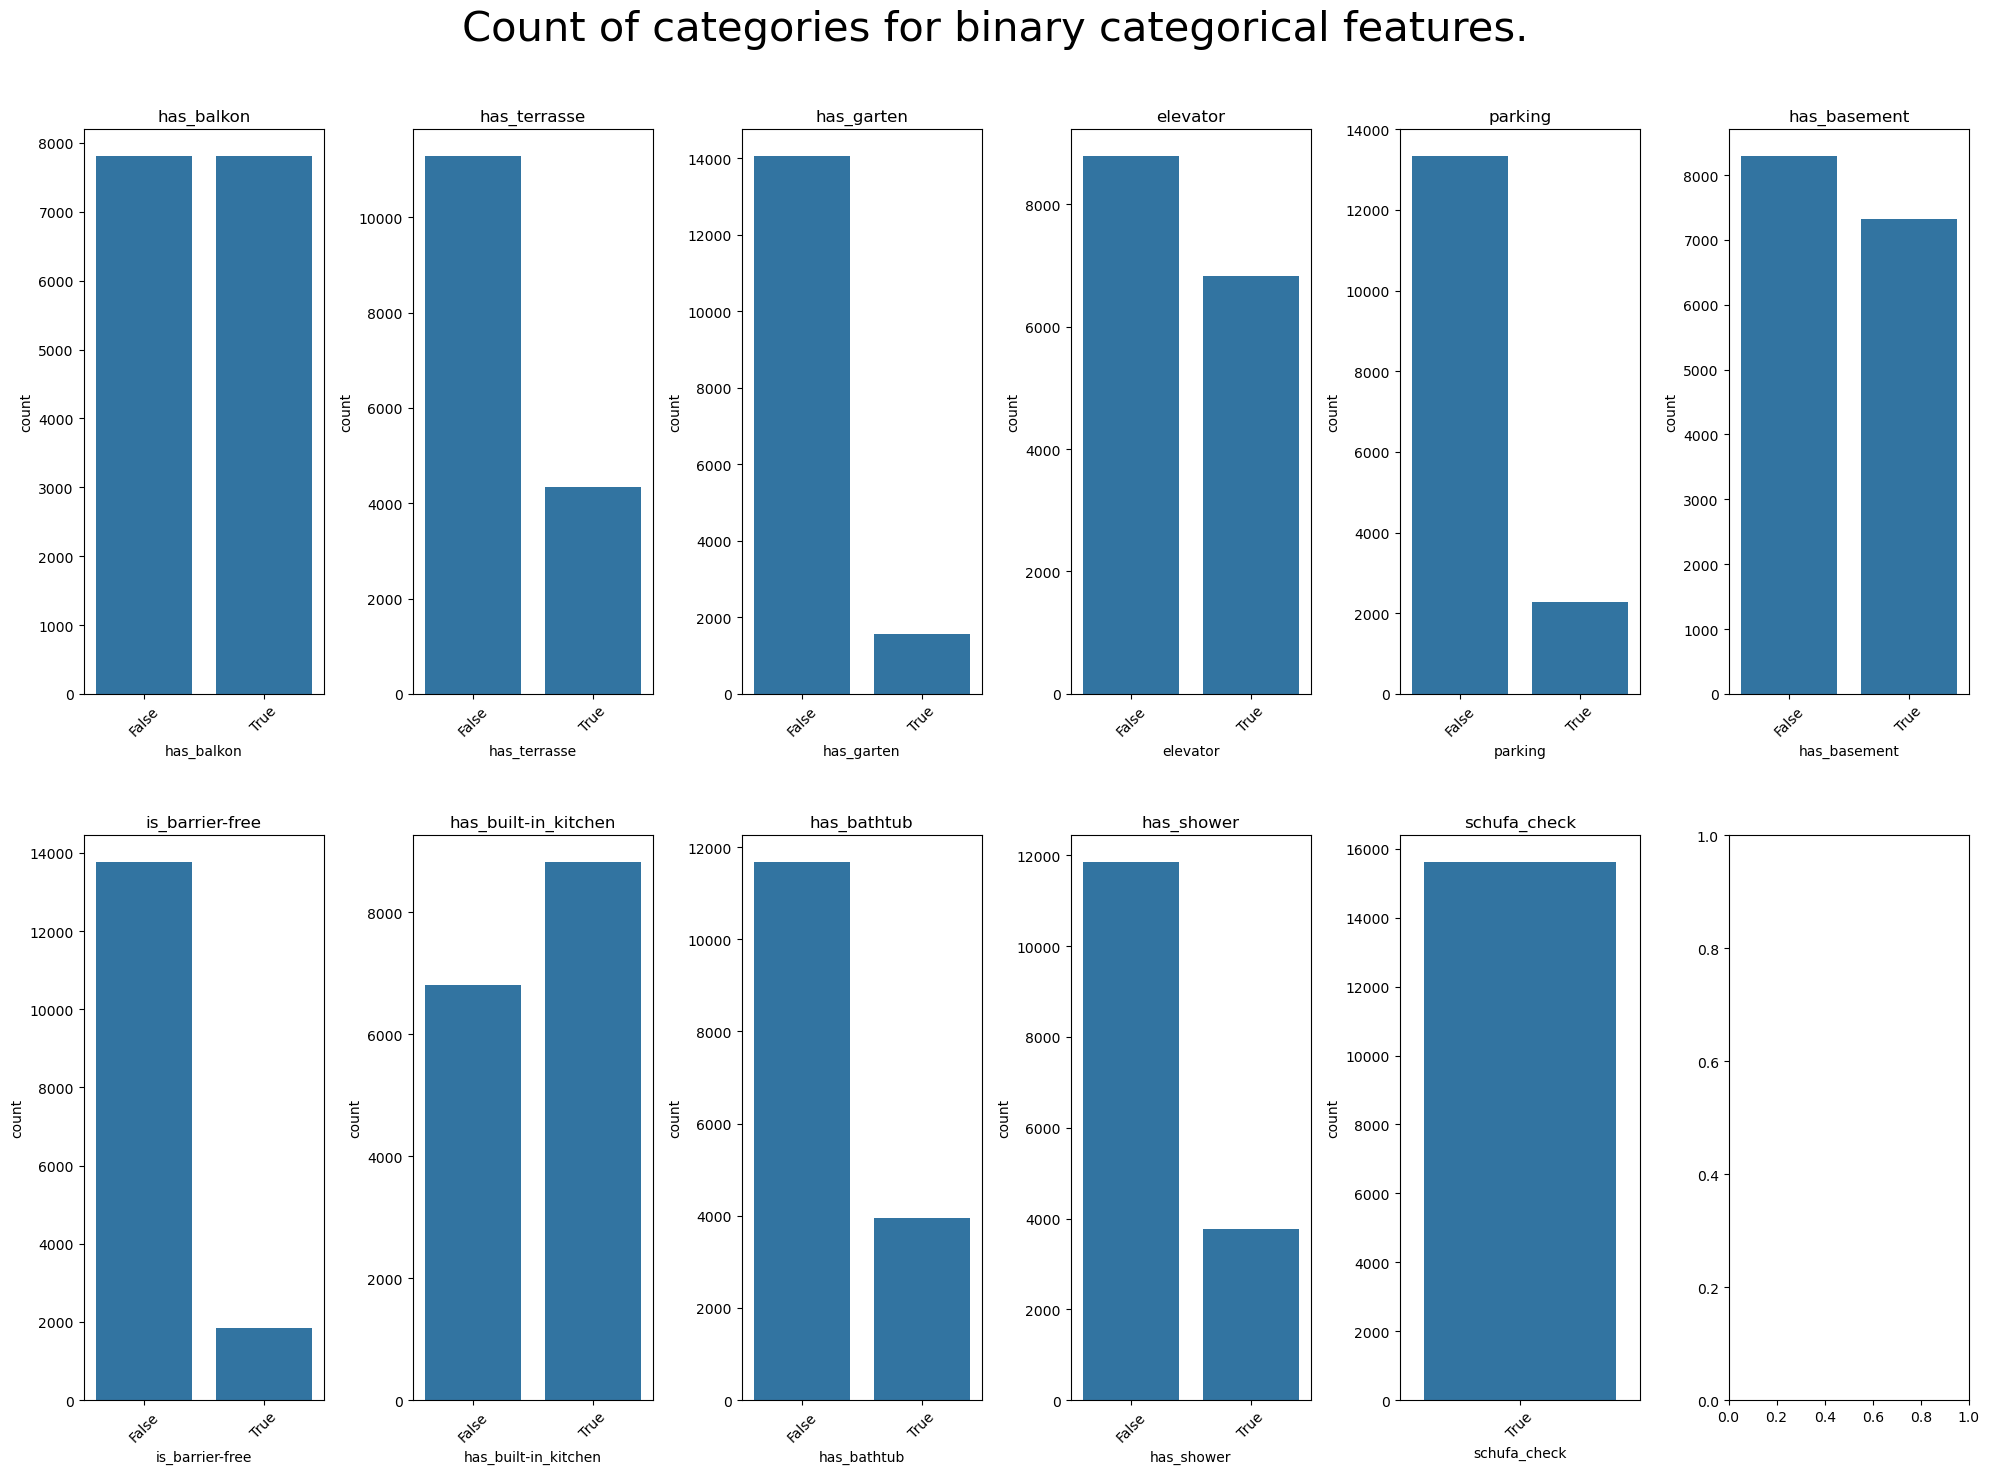

In [4]:
features = ['has_balkon', 'has_terrasse', 'has_garten','elevator','parking','has_basement','is_barrier-free','has_built-in_kitchen','has_bathtub','has_shower','schufa_check'] 

fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 15))
fig.suptitle("Count of categories for binary categorical features.",size=30)

for ax, feature in zip(axes.flatten(), features):
    sns.countplot(data=df, x=feature, ax=ax)  
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.25, top=0.9)
plt.show()

<span style="font-weight:500">
The majority of the apartments possess a built-in kitchen, which is a very important feature for an apartment. Half of them have a balcony and also features like an elevator and a basement are present in a considerable amount of apartments. While the rest of the features are not that common, they are still present in some of the apartments.
<br>
100% of the apartments require a SCHUFA_check, making this feature useless, therefore we have to drop it. We used to have 'false' values for this feature, but apparently they were dropped during the data cleaning process.
</span>

In [5]:
df = df.drop(columns="schufa_check")

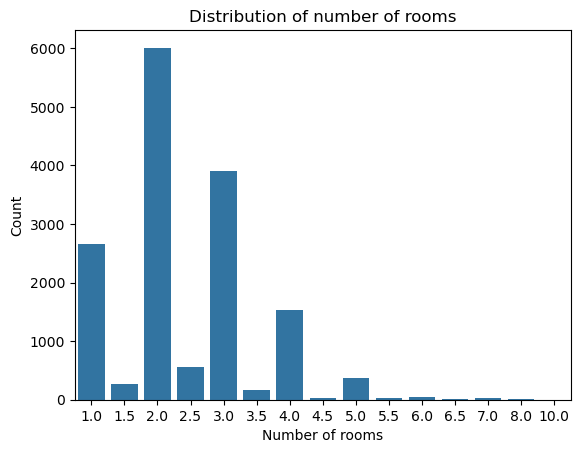

In [6]:
sns.countplot(data=df, x="rooms")
plt.title("Distribution of number of rooms")
plt.xlabel("Number of rooms")
plt.ylabel("Count")
plt.show()

<span style="font-weight:500">
Most of the apartments offer 2 rooms, followed by 3 rooms, 1 room and 4 rooms.
</span>

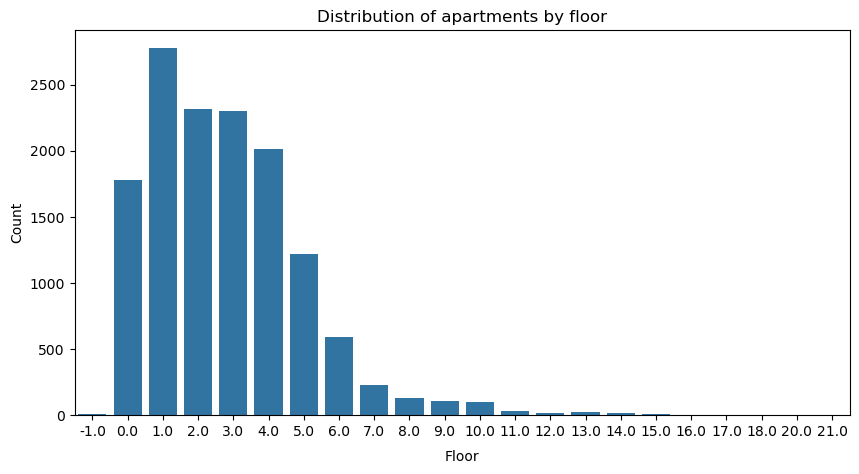

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="floor", ax=ax)

ax.xaxis.labelpad = 8
plt.title("Distribution of apartments by floor")
plt.xlabel("Floor")
plt.ylabel("Count")
plt.show()

In [8]:
df["floor"].value_counts()

floor
 1.0     2774
 2.0     2313
 3.0     2304
 4.0     2015
 0.0     1782
 5.0     1219
 6.0      594
 7.0      226
 8.0      128
 9.0      106
 10.0      99
 11.0      35
 13.0      23
 12.0      14
 14.0      13
-1.0       10
 15.0       6
 17.0       4
 16.0       3
 18.0       3
 21.0       1
 20.0       1
Name: count, dtype: int64

<span style="font-weight:500">
Encoding one additional dummy variable for categories that have very few occurences, such as any floor above the 10th floor would cause more noise rather than help the model learn new information. The best solution for this is to group these values together as one.
</span>

In [9]:
# we group anything above the 10th floor as 11th floor
df['floor'] = df['floor'].apply(
    lambda x: x if pd.isna(x) or x <= 10 else 11
)

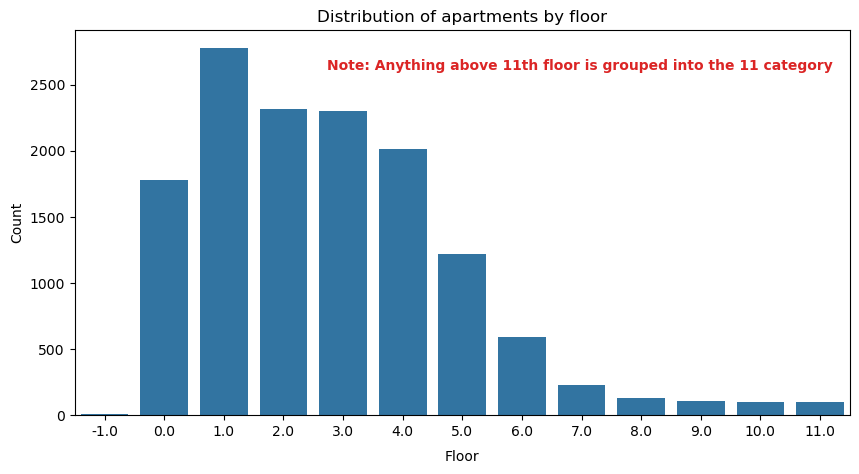

In [10]:
fig, ax = plt.subplots(figsize=(10, 5)) 
sns.countplot(data=df, x="floor", ax=ax) 
ax.xaxis.labelpad = 8 
fig.text(
    0.63, 0.8,
    "Note: Anything above 11th floor is grouped into the 11 category",
    ha='center',
    color="#db2525",
    fontweight='bold'
)
plt.title("Distribution of apartments by floor")
plt.xlabel("Floor")
plt.ylabel("Count")
plt.show()

<span style="font-weight:500">
Now we have a much more fair distribution of values, with the most values being between the 1st and the 4th floors. Also, a considerable number of apartments offer apartments on the ground and 5th floors.
</span>

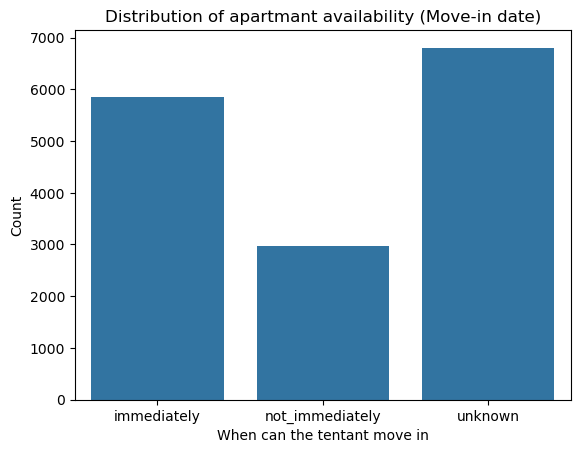

In [11]:
sns.countplot(data=df, x="free_from")
plt.xlabel("When can the tentant move in")
plt.ylabel("Count")
plt.title("Distribution of apartmant availability (Move-in date)")
plt.show()

<span style="font-weight:500">
If we exclude the samples where we don't have information, in about 2/3 of the remaining apartments, it is possible to move in immediately. </span>

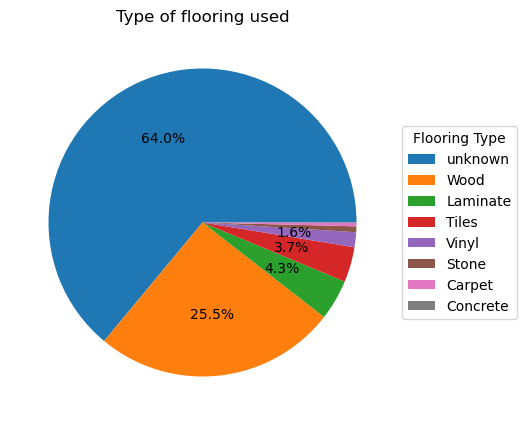

In [12]:
counts = df["flooring_type"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    labeldistance=1.2
)

plt.legend(
    counts.index,
    title="Flooring Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Type of flooring used")
plt.show()

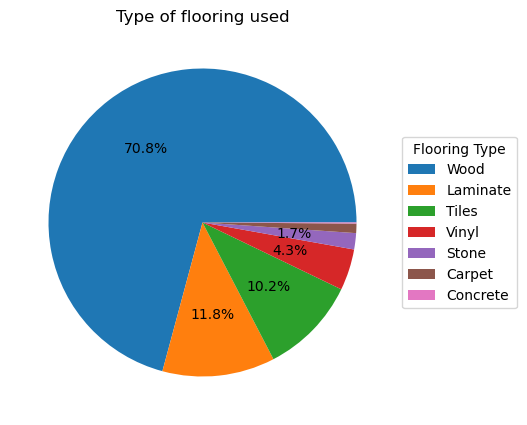

In [13]:
# If we exclude unknown
counts = df[df["flooring_type"] != "unknown"]["flooring_type"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    labeldistance=1.2
)

plt.legend(
    counts.index,
    title="Flooring Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Type of flooring used")
plt.show()

<span style="font-weight:500">
From the graph we notice that wood is pretty popular compared to the rest. While other types can still be present but in a narrow range of apartments.
</span>

In [14]:
# Let's take a further look into 'Concrete' 
df['flooring_type'].value_counts()

flooring_type
unknown     9993
Wood        3985
Laminate     665
Tiles        576
Vinyl        244
Stone         96
Carpet        56
Concrete       6
Name: count, dtype: int64

In [15]:
# only 6 samples that have this category. Let's inspect those values first.
df[df["flooring_type"] == "Concrete"]

,listing_url,cold_rent,area,rooms,floor,free_from,has_balkon,has_terrasse,has_garten,elevator,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,zip_code,district
1738,https://www.immowelt.de/expose/4261a90a-746d-4...,531.58,63.9,2.0,5.0,not_immediately,True,False,False,True,...,False,False,True,Concrete,District Heating,Unknown,Needs Renovation,1971.0,13435,Wittenau
2058,https://www.immowelt.de/expose/b9b8d537-b7c0-4...,531.58,63.9,2.0,5.0,not_immediately,True,False,False,True,...,False,False,True,Concrete,District Heating,Unknown,Needs Renovation,1971.0,13435,Wittenau
2069,https://www.immowelt.de/expose/684233d3-9f7a-4...,475.90,64.3,2.0,5.0,immediately,True,False,False,True,...,False,True,False,Concrete,District Heating,Unknown,Renovated,1970.0,13435,Wittenau
2555,https://www.immowelt.de/expose/684233d3-9f7a-4...,475.90,64.3,2.0,4.0,immediately,True,False,False,True,...,False,True,False,Concrete,District Heating,Unknown,Renovated,1970.0,13435,Wittenau
3356,https://www.immowelt.de/expose/617ad95e-a353-4...,341.86,39.6,1.0,3.0,immediately,True,False,False,True,...,False,True,False,Concrete,District Heating,Unknown,Renovated,1970.0,13435,Wittenau
5494,https://www.immowelt.de/expose/4d97a629-4fc1-4...,531.58,63.9,2.0,1.0,not_immediately,True,False,False,True,...,False,True,False,Concrete,District Heating,Unknown,Needs Renovation,1971.0,13435,Wittenau


In [16]:
# drop duplicates 
df = df.drop(index=[1738, 2069, 5494])

# for the rest change the values to 'Unknown' so we remove completely the 'Concrete' flooring type to avoid noise.
df.loc[[2058, 2555, 3356], 'flooring_type'] = 'unknown'

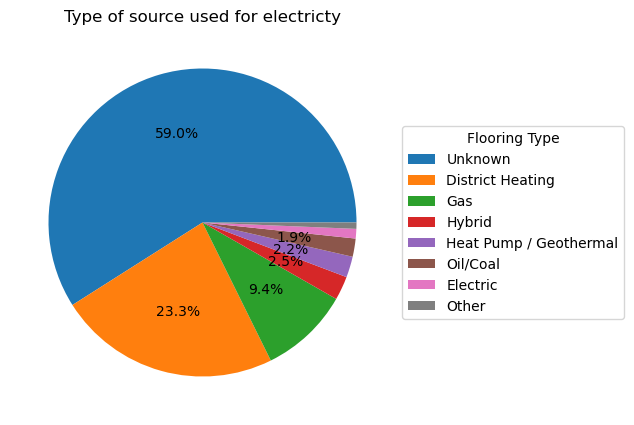

In [17]:
counts = df["energy_source"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    labeldistance=1.2
)

plt.legend(
    counts.index,
    title="Flooring Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Type of source used for electricty")
plt.show()

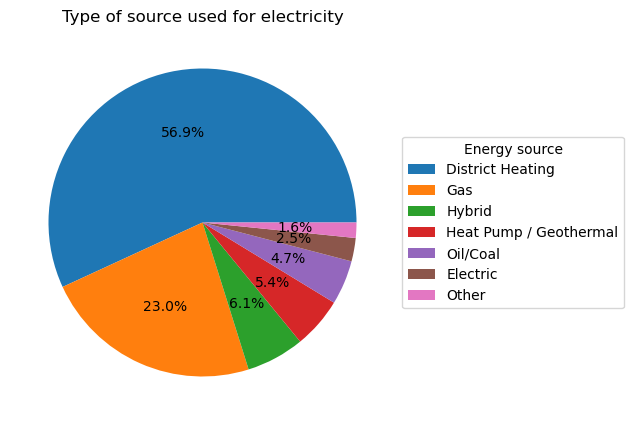

In [18]:
# If we exclude unknown
counts = df[df["energy_source"] != "Unknown"]["energy_source"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    labeldistance=1.2
)

plt.legend(
    counts.index,
    title="Energy source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Type of source used for electricity")
plt.show()

<span style="font-weight:500">
District Heating is the most popular and followed by gas. The rest are not very popular. </span>

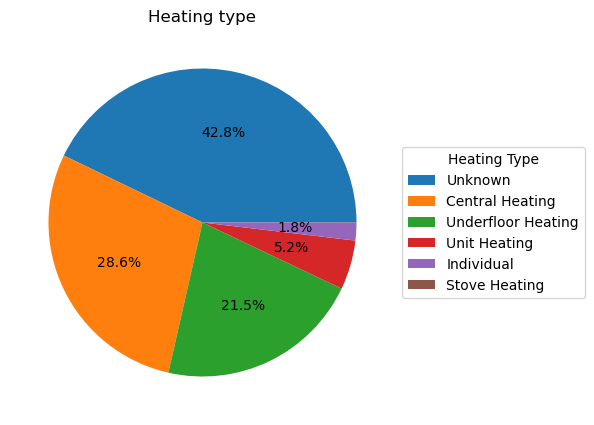

In [19]:
counts = df["heating_type"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    labeldistance=1.2
)

plt.legend(
    counts.index,
    title="Heating Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Heating type")
plt.show()

In [20]:
# Deeper look for the 'Stove Heating' type
df["heating_type"].value_counts()

heating_type
Unknown               6691
Central Heating       4467
Underfloor Heating    3357
Unit Heating           810
Individual             288
Stove Heating            5
Name: count, dtype: int64

In [21]:
df[df["heating_type"] == "Stove Heating"]

,listing_url,cold_rent,area,rooms,floor,free_from,has_balkon,has_terrasse,has_garten,elevator,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,zip_code,district
2175,https://www.immowelt.de/expose/30358959-c06c-4...,1172.83,69.0,2.0,5.0,immediately,False,False,False,False,...,False,False,False,unknown,Unknown,Stove Heating,Needs Renovation,NaN,10245,Friedrichshain
3006,https://www.immowelt.de/expose/30358959-c06c-4...,1172.83,69.0,2.0,4.0,immediately,False,False,False,False,...,False,False,False,unknown,Unknown,Stove Heating,Needs Renovation,NaN,10245,Friedrichshain
3881,https://www.immowelt.de/expose/30358959-c06c-4...,1172.83,69.0,2.0,3.0,immediately,False,False,False,False,...,False,False,False,unknown,Unknown,Stove Heating,Needs Renovation,NaN,10245,Friedrichshain
4178,https://www.immowelt.de/expose/30358959-c06c-4...,1172.83,69.0,2.0,2.0,immediately,False,False,False,False,...,False,False,False,unknown,Unknown,Stove Heating,Needs Renovation,NaN,10245,Friedrichshain
5904,https://www.immowelt.de/expose/2e141c4a-cfb4-4...,1172.83,69.0,2.0,1.0,immediately,True,False,False,False,...,False,True,False,Wood,Unknown,Stove Heating,Renovated,NaN,10245,Friedrichshain


In [22]:
# These samples will just confuse our model so we just keep 2 and change their heating_type to 'Unknown', this way we have
# one less category.

# drop duplicates 
df = df.drop(index=[2175, 3006, 4178])

# for the rest change the values to 'Unknown'
df.loc[[3881, 5904], 'heating_type'] = 'Unknown'

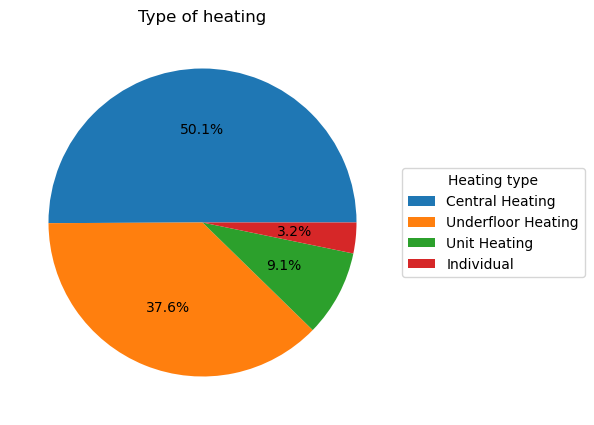

In [23]:
# If we exclude unknown
counts = df[df["heating_type"] != "Unknown"]["heating_type"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    labeldistance=1.2
)

plt.legend(
    counts.index,
    title="Heating type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Type of heating")
plt.show()

<span style="font-weight:500">
If we exclude the samples whose heating type is not known, we have the Central Heating as the most popular form of heating with half of the apartments, followed by Underfloor heating with around one third. I didn't except Underfloor heating to be this popular since it is more expensive than the rest. Unit heating and Individual Heating are not as popular as the other two. </span>

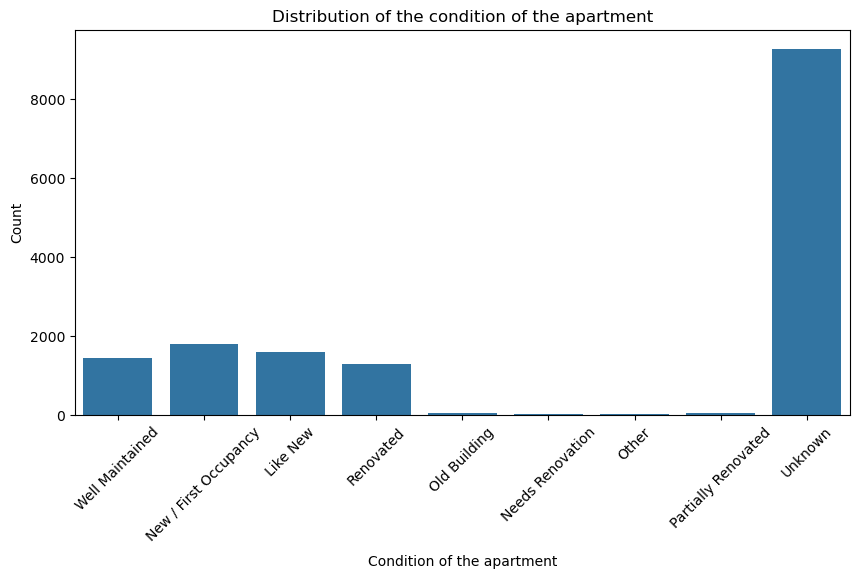

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="property_condition", ax=ax)

ax.xaxis.labelpad = 8
plt.xticks(rotation=45)
plt.xlabel("Condition of the apartment")
plt.ylabel("Count")
plt.title("Distribution of the condition of the apartment")
plt.show()

In [25]:
df["property_condition"].value_counts()

property_condition
Unknown                  9284
New / First Occupancy    1796
Like New                 1609
Well Maintained          1453
Renovated                1305
Old Building               56
Partially Renovated        44
Other                      35
Needs Renovation           33
Name: count, dtype: int64

<span style="font-weight:500">
Every category contains meaningful information, so we cannot drop any of them, even though they occur in very few samples compared to the rest of the categories. Some of the categories might seem very similar to each other, but they carry slightly different meanings, so we cannot merge them without losing information. Also, we don't have many categories, so we don't have the pressure of merging them. </span>

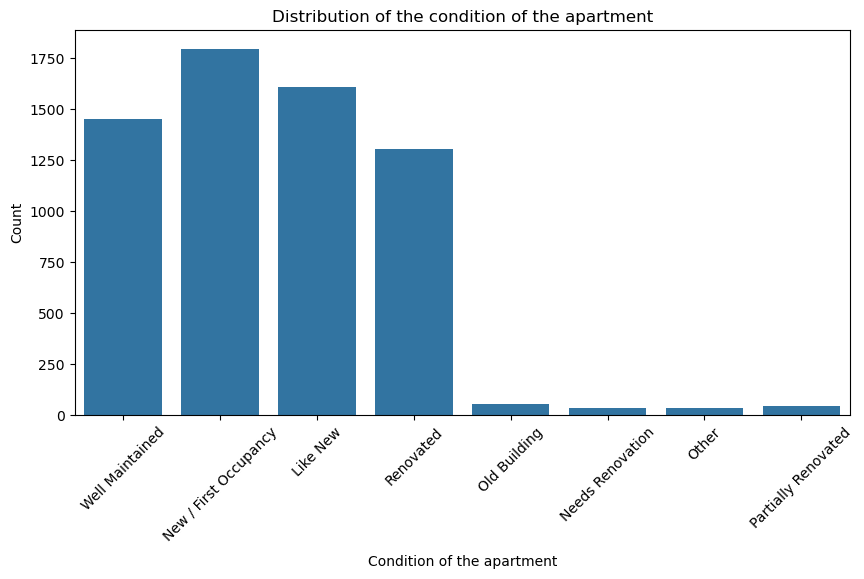

In [26]:
# If we exclude unknown
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df[df["property_condition"] != "Unknown"], x="property_condition")
plt.title("Condition of the apartment")
ax.xaxis.labelpad = 8
plt.xticks(rotation=45)
plt.xlabel("Condition of the apartment")
plt.ylabel("Count")
plt.title("Distribution of the condition of the apartment")
plt.show()

<span style="font-weight:500">
We notice a huge difference between the first 4 categories, which occur very often and the other 4 categories, which occur very rarely. The first 4 categories make up most of the apartments (if we exclude unknown) and the other 4, which are associated with negative meaning, make up only a tiny portion of the apartments. Looking at this graph, we might get confused and conclude that almost every apartment in Berlin is in a very good condition, which is not true because we are leaving out the "unknown" category. We can definitely hypothesize that the 'Unknown' category will have some negative impact on the price and condition of the apartment. We might reveal this information later when we do the Bivariate Analysis or if our model picks up these patterns. </span>

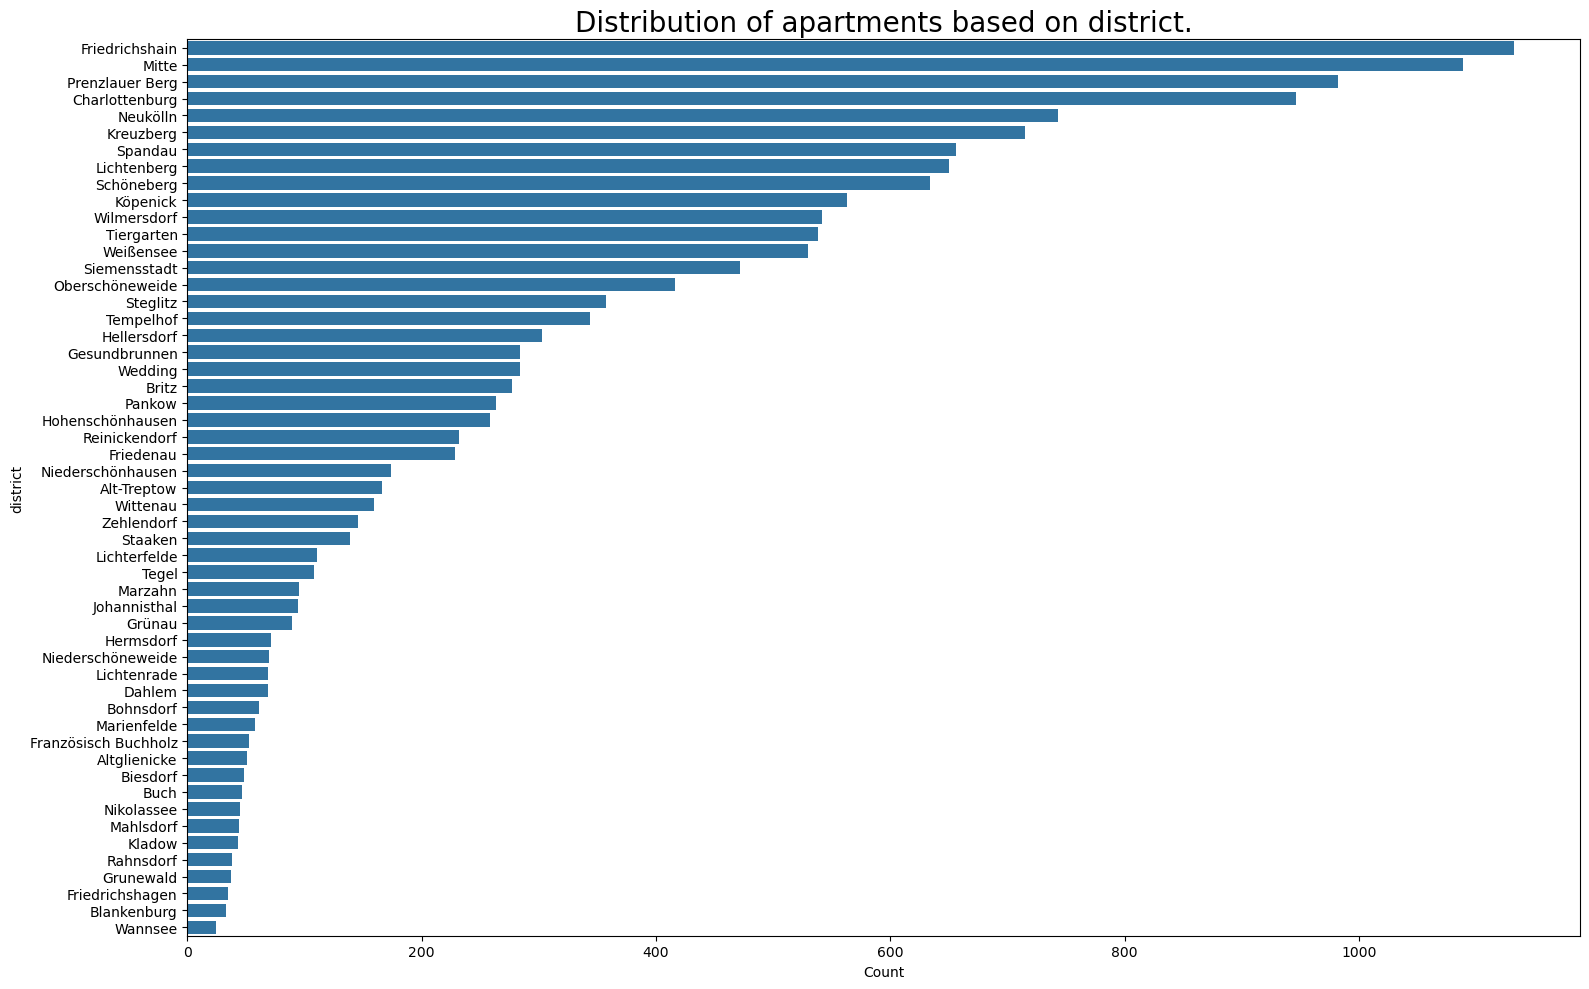

In [27]:
plt.figure(figsize=(16, 10))
sns.countplot(data=df, y="district", order=df["district"].value_counts().index)
plt.title('Distribution of apartments based on district.',size=20)
plt.xlabel('Count')
plt.tight_layout()
plt.show()

<span style="font-weight:500">
The most popular area is Friedrichshain followed by Mitte, Prenzlauer Berg, Charlottenburg, Neukölln, Kreuzberg and so on. </span>

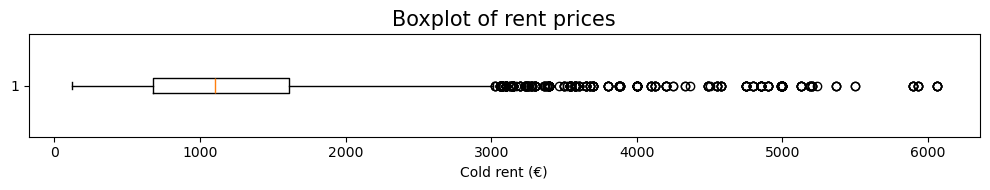

In [28]:
plt.figure(figsize=(10, 2))
plt.boxplot(df["cold_rent"],vert=False)
plt.title('Boxplot of rent prices',size=15)
plt.xlabel('Cold rent (€)')
plt.tight_layout()
plt.show()

<span style="font-weight:500">
We already dropped the top 1% of values as outliers and decided to keep everything below 6000 euros. I wouldn't say all those points are outliers and should not be dropped. </span>

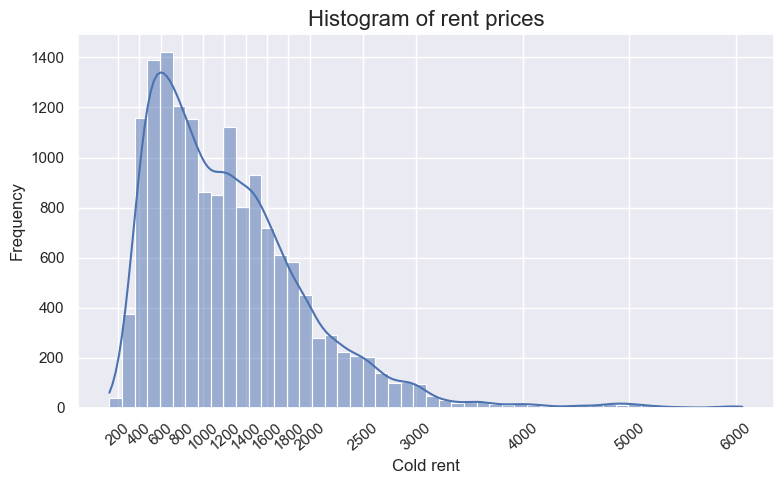

In [29]:
plt.figure(figsize=(8, 5))
sns.set(style="darkgrid")

ax = sns.histplot(
    df["cold_rent"],
    bins=50,
    kde=True,
)

ticks = [200,400,600,800,
         1000,1200,1400,1600,1800,2000,2500,
         3000,4000,5000,6000]

ax.set_xticks(ticks)
plt.xticks(rotation=40)

plt.title('Histogram of rent prices', size=16)
plt.xlabel('Cold rent')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<span style="font-weight:500">
The distribution of rent prices has a high positive skewness and is mostly focused between 500 and 2000. </span>

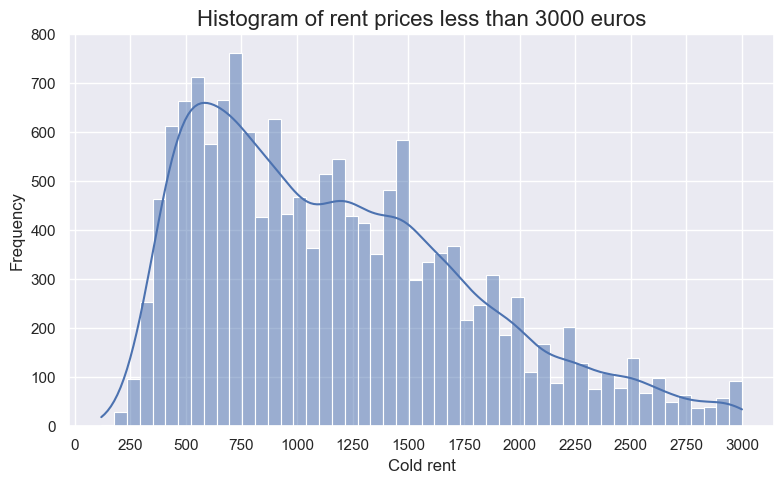

In [30]:
plt.figure(figsize=(8, 5))
sns.set(style="darkgrid")

plot_df = df[df["cold_rent"] <= 3000]

ax = sns.histplot(
    plot_df["cold_rent"],
    bins=50,
    kde=True
)

ticks = np.linspace(0,3000,13)

ax.set_xticks(ticks)

plt.title('Histogram of rent prices less than 3000 euros', size=16)
plt.xlabel('Cold rent')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<span style="font-weight:500">
The most common price is around 750 euros and with most of the samples distributed around 600 euros. Inside the range of 1000-1500 there is also a huge cluster of samples distributed. We can notice some spikes at certain values such as 750, 1200 and 1500.</span>

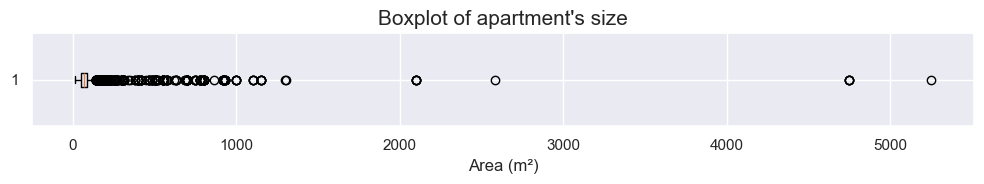

In [31]:
plt.figure(figsize=(10, 2))
plt.boxplot(df["area"],vert=False)
plt.title("Boxplot of apartment's size",size=15)
plt.xlabel('Area (m²)')
plt.tight_layout()
plt.show()

In [32]:
len(df[df["area"] > 2000])

11

In [33]:
# 11 values out 15500 should definitely treated as outliers. This is clearly shown by the boxplot we just plotted.
# They only harm out model so they should be dropped.
df = df[df["area"] < 2000]

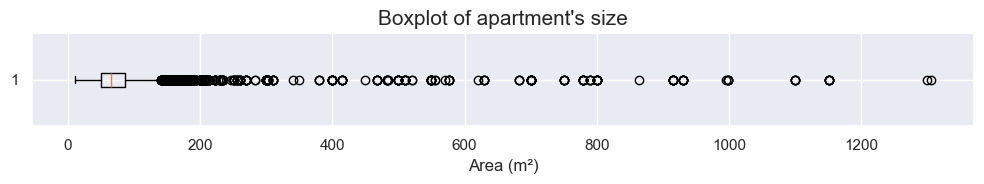

In [34]:
plt.figure(figsize=(10, 2))
plt.boxplot(df["area"],vert=False)
plt.title("Boxplot of apartment's size",size=15)
plt.xlabel('Area (m²)')
plt.tight_layout()
plt.show()

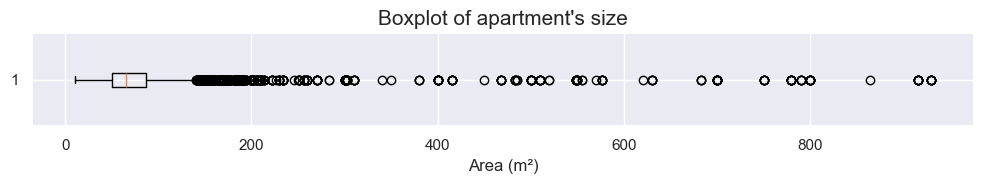

In [35]:
# Those dots from starting from 1000 also seem as outliers that harm our models so let's remove them
df = df[df["area"] < 950]

plt.figure(figsize=(10, 2))
plt.boxplot(df["area"],vert=False)
plt.title("Boxplot of apartment's size",size=15)
plt.xlabel('Area (m²)')
plt.tight_layout()
plt.show()

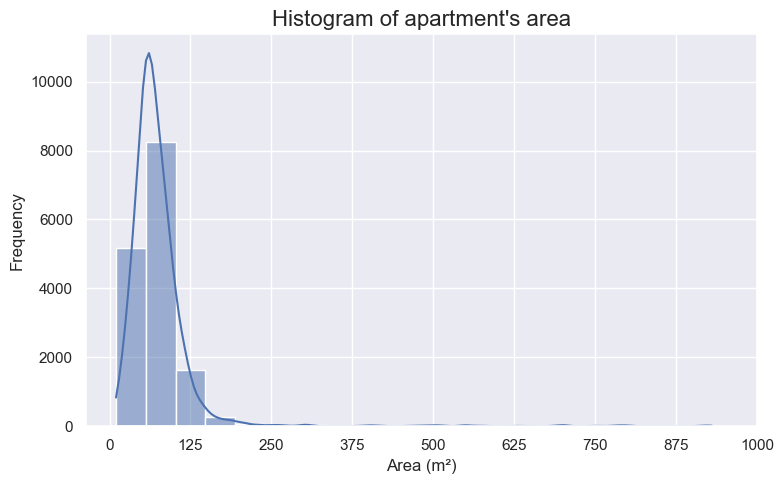

In [36]:
# Let's also plot the histogram and distribution of values to get more information
plt.figure(figsize=(8, 5))
sns.set(style="darkgrid")

ax = sns.histplot(
    df["area"],
    bins=20,
    kde=True
)

ticks = np.linspace(0,1000,9)

ax.set_xticks(ticks)

plt.title("Histogram of apartment's area", size=16)
plt.xlabel('Area (m²)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<span style="font-weight:500">
The distribution has a very long right tail and most values are distributed around 50 square meters.</span>

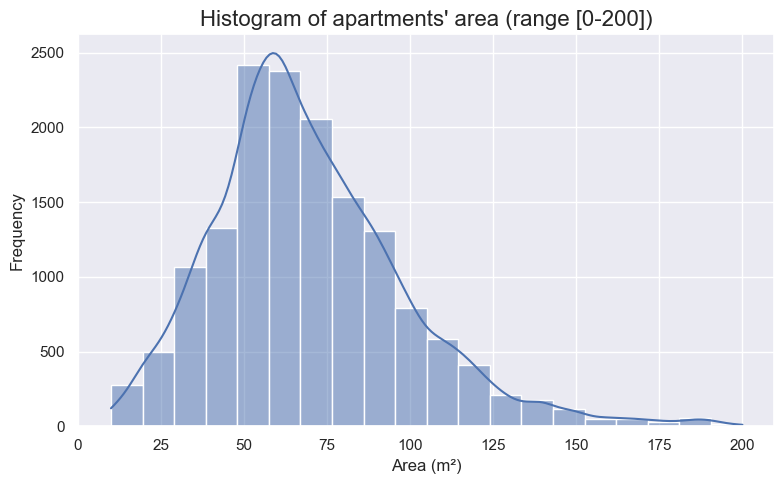

In [37]:
plt.figure(figsize=(8, 5))
sns.set(style="darkgrid")

ax = sns.histplot(
    df[df["area"]<=200]["area"],
    bins=20,
    kde=True
)

ticks = np.linspace(0,200,9)

ax.set_xticks(ticks)

plt.title("Histogram of apartments' area (range [0-200])", size=16)
plt.xlabel('Area (m²)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<span style="font-weight:500">
It looks normally distributed around this common area range.</span>

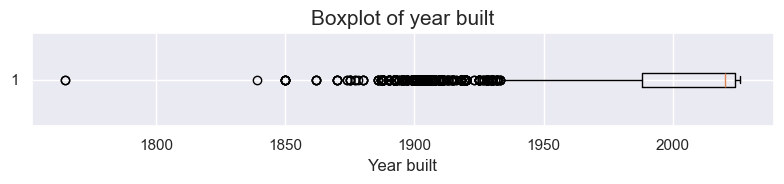

In [38]:
plt.figure(figsize=(8, 2))

plt.boxplot(df["year_built"].dropna(), vert=False)

plt.title("Boxplot of year built", size=15)
plt.xlabel("Year built")

plt.tight_layout()
plt.show()

In [39]:
df["year_built"].describe()

count    7662.000000
mean     1996.980684
std        43.904575
min      1765.000000
25%      1988.000000
50%      2020.000000
75%      2024.000000
max      2026.000000
Name: year_built, dtype: float64

<span style="font-weight:500">
It is pretty interesting how we have only one apartment way older than the others, built in the year 1765.
<br>
From this boxplot, it is not very easy to get a lot of information, so let's also plot the distribution of values.</span>

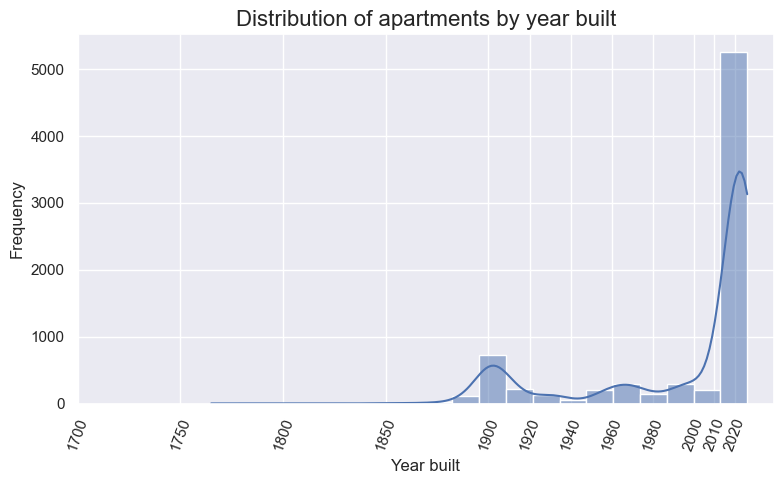

In [40]:
plt.figure(figsize=(8, 5))
sns.set(style="darkgrid")

ax = sns.histplot(
    df["year_built"].dropna(),
    bins=20,
    kde=True
)

ticks = [1700,1750,1800,1850,1900,1920,1940,1960,1980,2000,2010,2020]

ax.set_xticks(ticks)

plt.title("Distribution of apartments by year built", size=16)
plt.xlabel('Year built')
plt.ylabel('Frequency')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

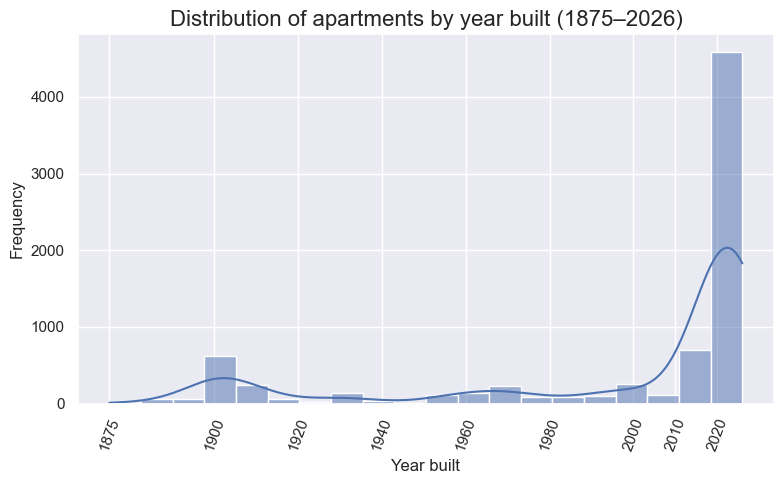

In [41]:
plt.figure(figsize=(8, 5))
sns.set(style="darkgrid")

ax = sns.histplot(
    df[df["year_built"] >= 1875]["year_built"],
    bins=20,
    kde=True
)

ticks = [1875,1900,1920,1940,1960,1980,2000,2010,2020]

ax.set_xticks(ticks)

plt.title("Distribution of apartments by year built (1875–2026)", size=16)
plt.xlabel('Year built')
plt.ylabel('Frequency')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

<span style="font-weight:500">
It is fascinating to see how both World Wars clearly caused the number of apartments built to drop.
<br>
Also, most of the apartments being rented out were built during the last 7 years. That makes sense considering the fact that old apartments are taken by locals.
</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 2: Understanding relationships between variables</span>

In [42]:
# For this section we will use altair for more interactive and detailed views

import altair as alt

alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [ ]:
alt.Chart(df).mark_circle(opacity=0.3, size=100).encode(
    x=alt.X("area:Q", title="Area"),
    y=alt.Y("cold_rent:Q", title="Cold rent"),
    color=alt.Color(
        "rooms:O",
        title="Rooms",
        scale=alt.Scale(scheme="oranges")
    ),
    tooltip=["area", "cold_rent", "rooms"]
).properties(
    width=700,
    height=450,
    title="Impact of area size and number of rooms on price"
).interactive()

<span style="font-weight:500">
As expected, a positive correlation, we have a very strong positive correlation, especially if we exclude apartments with areas larger than 200 meters. Similar trend is seen with the number of rooms, a bigger area would mean a large number of rooms.
</span>

In [ ]:
alt.Chart(df[df["area"] <= 220]).mark_circle(opacity=0.3, size=100).encode(
    x=alt.X("area:Q", title="Area"),
    y=alt.Y("cold_rent:Q", title="Cold rent"),
    color=alt.Color(
        "rooms:O",
        title="Rooms",
        scale=alt.Scale(scheme="oranges")
    ),
    tooltip=["area", "cold_rent", "rooms"]
).properties(
    width=700,
    height=450,
    title="Impact of area size and number of rooms on price"
).interactive()

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(np.array(df[df["area"] <= 220]["area"].tolist()).reshape(-1, 1), np.array(df[df["area"] <= 220]["cold_rent"].tolist()).reshape(-1, 1))

print("Coefficients:", model.coef_)

print("Intercept:", model.intercept_)

Coefficients: [[15.23415299]]
Intercept: [146.79003249]


<span style="font-weight:500">
We model a simple regression to see the relationship between rent and area size. The modeled regression is the following:
<br>
cold_rent = 146.79 + 15.23*area
<br>
Meaning an additional square meter would increase the price by 15.23 euro on average. For example, an apartment with an area of 20 square meters would have a cold rent of 146.79 + 15.23 * 20 = 451.39, which is very accurate, judging by what we have seen so far.
</span>

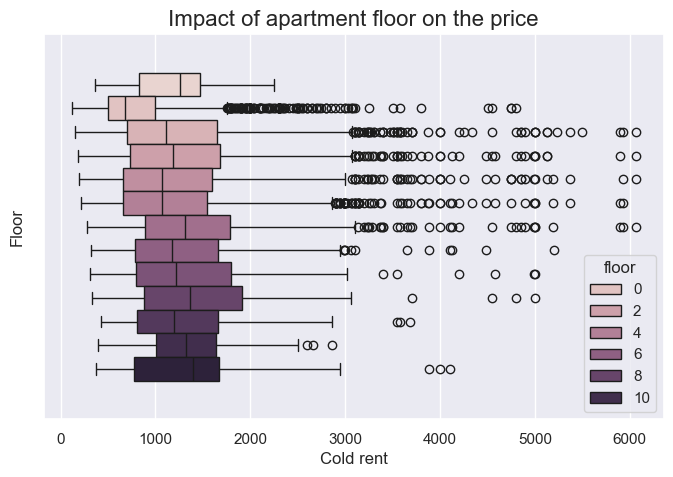

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cold_rent", hue="floor", data=df)
plt.title("Impact of apartment floor on the price", size=16)
plt.xlabel("Cold rent")
plt.ylabel("Floor")
plt.show()

<span style="font-weight:500">
It is not very easy to tell with 100% confidence from the graph whether the floor affects the price or not. The best way would be to make a statistical test, the Kruskal–Wallis test, to be more specific. This test is more appropirate over One-way ANOVA because we have non-parametric data.
<br>
H0: The population medians of cold rent are equal across floors
<br>
H1: At least one group differs
</span>

In [45]:
from scipy.stats import kruskal

groups = [group["cold_rent"].values 
          for name, group in df.groupby("floor")]

stat, p = kruskal(*groups)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 905.2321614512542
p-value: 4.3213145794236566e-186


<span style="font-weight:500">
For p < 0.05 we reject the null hypothesis, therefore we can say that there is clearly a difference between the price distributions for different floors.
</span>

<span style="font-weight:500">
We could argue that the result for that might be the one floor category that is visibly skewed more left than the others. Let's redo the test by excluding that category.
</span>

In [46]:
df_test = df[df["floor"] != 0]

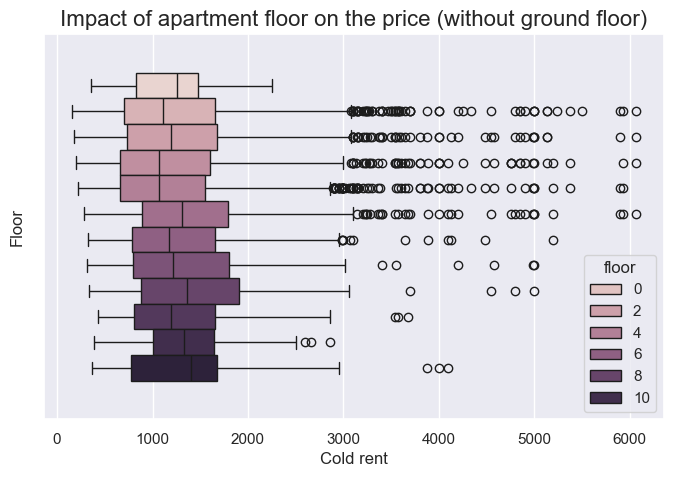

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cold_rent", hue="floor", data=df_test)
plt.title("Impact of apartment floor on the price (without ground floor)", size=16)
plt.xlabel("Cold rent")
plt.ylabel("Floor")
plt.show()

In [48]:
groups = [group["cold_rent"].values 
          for name, group in df_test.groupby("floor")]

stat, p = kruskal(*groups)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 133.2379576086209
p-value: 3.8455928357470373e-23


<span style="font-weight:500">
We reject the null hypothesis again, meaning they still have different distributions. This time we can clearly notice the impact of the ground floor category by observing the huge increase in the value of p.
</span>

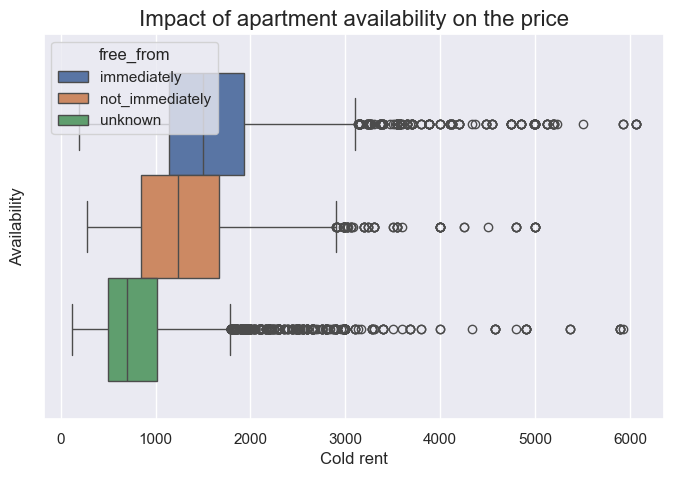

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cold_rent", hue="free_from", data=df)
plt.title("Impact of apartment availability on the price", size=16)
plt.xlabel("Cold rent")
plt.ylabel("Availability")
plt.show()

<span style="font-weight:500">
The impact here is noticeable and turns out to be as expected. Apartments that are available immediately are more likely to be more expensive compared to those that require a waiting time before moving in. When there is an uncertainty on the availability, the price is expected to be even lower.
</span>

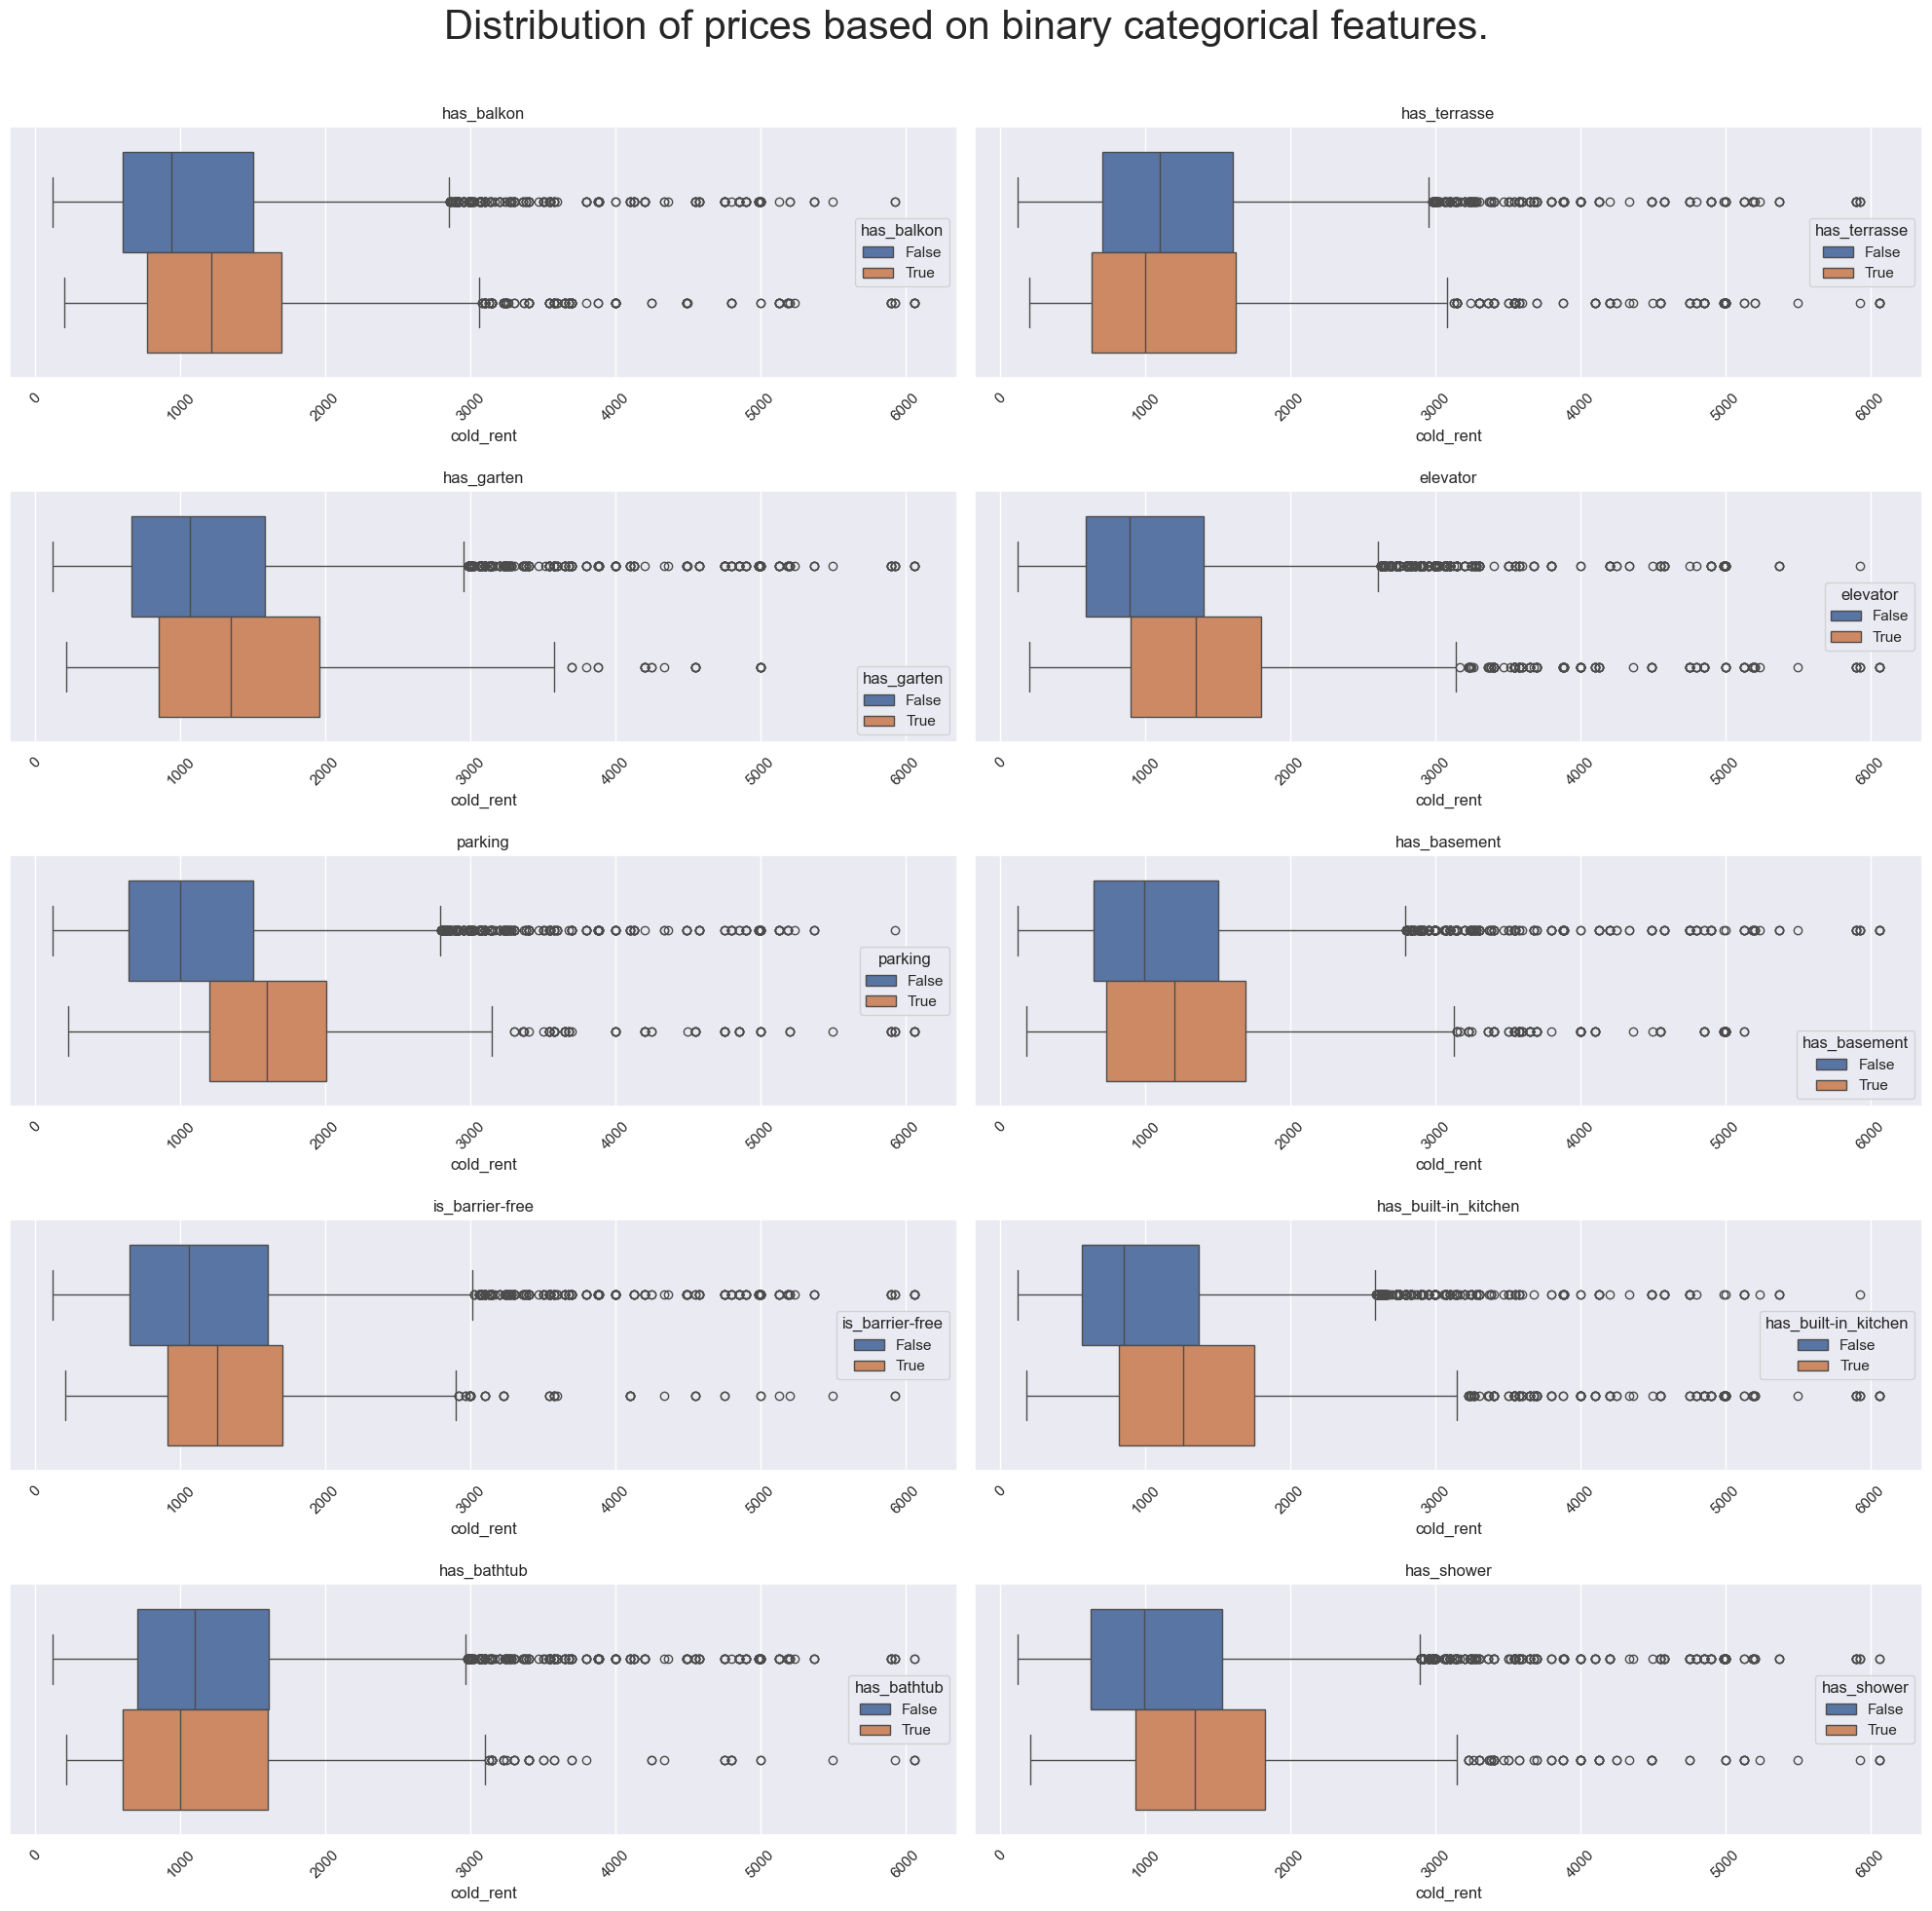

In [50]:
features = ['has_balkon', 'has_terrasse', 'has_garten','elevator','parking','has_basement','is_barrier-free','has_built-in_kitchen','has_bathtub','has_shower'] 

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 20))
fig.suptitle("Distribution of prices based on binary categorical features.",size=30)

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="cold_rent", hue=feature, ax=ax)  
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, top=0.92)
plt.show()

<span style="font-weight:500">
We can notice that if an apartment possesses a feature, it tends to be more expensive, with some of the features having a slightly stronger effect than the others, for example having a shower, a park, an elevator or a built-in kitchen makes a greater difference compared to the other features.
<br>
Features like "has_terrasse" and "has_bathtub" have no clear difference on the price distribution. 
</span>

In [51]:
terrasse = df.groupby("has_terrasse").agg({
    "cold_rent": ["mean", "median"],
    "area": ["mean", "median"],
    "rooms": ["mean", "median"]
})

bathtub = df.groupby("has_bathtub").agg({
    "cold_rent": ["mean", "median"],
    "area": ["mean", "median"],
    "rooms": ["mean", "median"]
})

comparison = pd.concat(
    [terrasse, bathtub],
    keys=["has_terrasse", "has_bathtub"],
    names=["feature"]
)

comparison

cold_rent               area            rooms  \
                                  mean  median       mean median      mean   
feature      has_terrasse                                                    
has_terrasse False         1235.880492  1100.0  69.770132   63.0  2.319081   
             True          1236.613001  1000.0  89.696501   71.0  2.630939   
has_bathtub  False         1253.785192  1100.0  72.344785   63.0  2.318622   
             True          1183.572041   997.0  84.011094   72.0  2.662850   

                                  
                          median  
feature      has_terrasse         
has_terrasse False           2.0  
             True            2.5  
has_bathtub  False           2.0  
             True            2.5

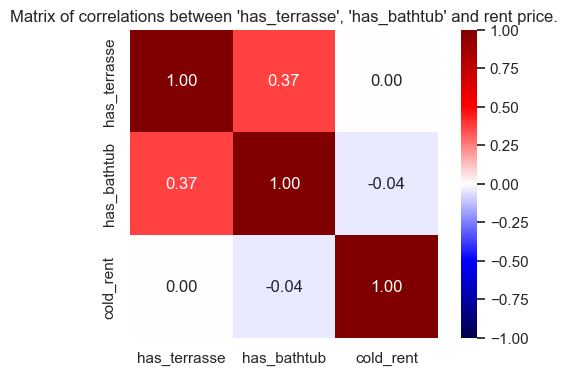

In [52]:
corr = df[["has_terrasse", "has_bathtub", "cold_rent"]].corr()

# mask where absolute correlation is below 0.3

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", square=True, 
            cmap="seismic", vmin=-1, vmax=1)
plt.title("Matrix of correlations between 'has_terrasse', 'has_bathtub' and rent price.")
plt.show()

<span style="font-weight:500">
Apartments with terraces and bathtubs show a lower rental-price distribution in the dataset. This is an unexpected association, as these features would generally be expected to increase an apartment's attractiveness. However, this descriptive relationship does not imply causation.
<br/> 
Despite this distribution, there is no correlation between these rent prices and any of these features. However, worth mentioning is the correlation between these 2 features itself, which is quite significant. This might be something we have to look after.
<br/>
We will keep this in mind when we train our model to see how these 2 features will impact its behavior and performance.
</span>

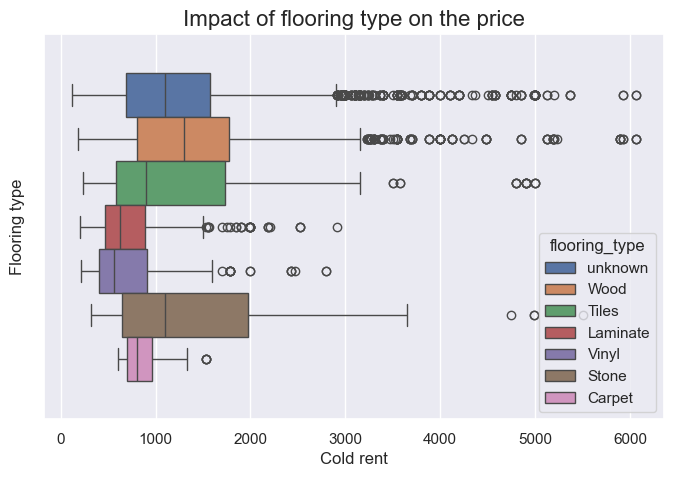

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cold_rent", hue="flooring_type", data=df)
plt.title("Impact of flooring type on the price", size=16)
plt.xlabel("Cold rent")
plt.ylabel("Flooring type")
plt.show()

<span style="font-weight:500">
This feature turns out to be economically meaningful, with certain good materials such as wood, stone and tiles being associated with higher rent compared to materials like carpet, vinyl and laminate, which correspond to lower rent prices.
</span>

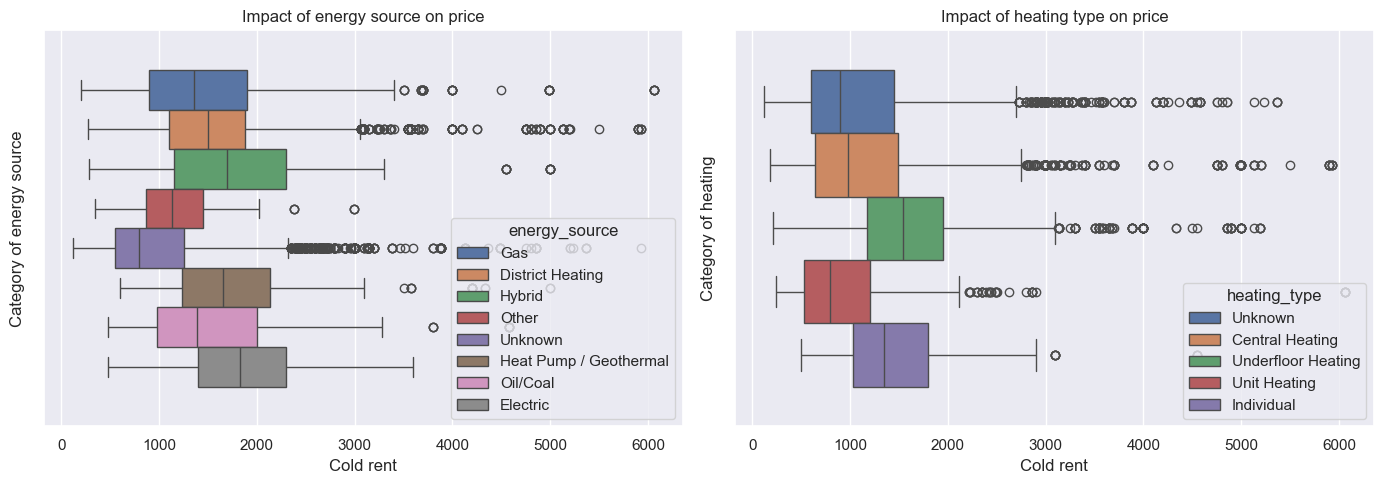

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="cold_rent", hue="energy_source", data=df, ax=axes[0])
axes[0].set_title("Impact of energy source on price")
axes[0].set_xlabel("Cold rent")
axes[0].set_ylabel("Category of energy source")

sns.boxplot(x="cold_rent", hue="heating_type", data=df, ax=axes[1])
axes[1].set_title("Impact of heating type on price")
axes[1].set_xlabel("Cold rent")
axes[1].set_ylabel("Category of heating")

plt.tight_layout()
plt.show()

<span style="font-weight:500">
On the left graph we see the distribution of rent prices based on different energy sources. We notice that when we don't have information about the energy sources used, we tend to have lower prices. Unlike other categories, this time not knowing the category is associated with a strong negative effect. Features like Hybrid and Electric are associated with higher prices of rent compared to the others, but overall they tend to have a relatively similar distribution if we exclude the "Unknown" and "Other" features.
<br>
On the right graph we see the distribution of rent prices based on different heating types. As expected, underfloor heating is associated with higher rent prices. Also, individual heating tends to have higher prices, similar to underfloor heating, while the rest of the categories have a lower distribution, with unit heating having the lowest.
</span>

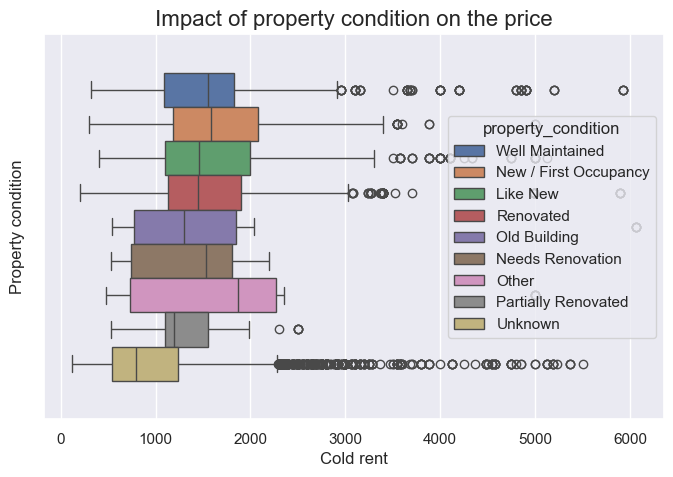

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cold_rent", hue="property_condition", data=df)
plt.title("Impact of property condition on the price", size=16)
plt.xlabel("Cold rent")
plt.ylabel("Property condition")
plt.show()

<span style="font-weight:500">
Unlike most of the features, this time the results seem to be slightly economically unsatisfactory, because we notice features like "Needs Renovation" to be associated on average with higher prices than apartments that are in good condition. But when we compare the categories associated with a positive impact, they tend to be associated with higher prices than features like "Partially Renovated", "Old Building" or when the property is not mentioned at all, it tends to be associated with even lower prices.
</span>

In [ ]:
district_stats = (
    df.groupby("district")
      .agg(
          median_rent=("cold_rent", "median"),
          n=("cold_rent", "size")
      )
      .reset_index()
)

overall_median = df["cold_rent"].median()

bars = alt.Chart(district_stats).mark_bar().encode(
    x=alt.X(
        "median_rent:Q",
        title="Median cold rent (€)"
    ),
    y=alt.Y(
        "district:N",
        sort="-x",
        title="District"
    ),
    tooltip=[
        "district:N",
        alt.Tooltip(
            "median_rent:Q",
            title="Median rent",
            format=".0f"
        ),
        alt.Tooltip(
            "n:Q",
            title="Number of apartments"
        )
    ]
)

median_rule = alt.Chart(
    pd.DataFrame({"overall_median": [overall_median]})
).mark_rule(
    strokeDash=[5, 5],
    size=2
).encode(
    x=alt.X("overall_median:Q"),
    tooltip=[
        alt.Tooltip(
            "overall_median:Q",
            title="Overall median",
            format=".0f"
        )
    ]
)

(bars + median_rule).properties(
    width=600,
    height=700,
    title="Median cold rent by district"
)

<span style="font-weight:500">
As expected, the distribution of rent prices through different districts differs a lot and we can expect these features to be one of the most influential features. 
</span>

In [ ]:
brush = alt.selection_interval(encodings=["x"])

rent_hist = (
    alt.Chart(df)
    .mark_bar()
    .encode(
        x=alt.X(
            "cold_rent:Q",
            bin=alt.Bin(maxbins=50),
            title="Cold rent (€)"
        ),
        y=alt.Y(
            "count()",
            title="Number of apartments"
        ),
        color=alt.condition(
            brush,
            alt.value("steelblue"),
            alt.value("lightgray")
        ),
        tooltip=[
            alt.Tooltip("count()", title="Apartments")
        ]
    )
    .add_params(brush)
    .properties(
        width=500,
        height=500,
        title="Distribution of cold rent"
    )
)

district_chart = (
    alt.Chart(df)
    .transform_filter(brush)
    .mark_bar()
    .encode(
        y=alt.Y(
            "district:N",
            sort="-x",
            title="District"
        ),
        x=alt.X(
            "count():Q",
            title="Number of apartments"
        ),
        tooltip=[
            alt.Tooltip("district:N", title="District"),
            alt.Tooltip("count():Q", title="Apartments")
        ]
    )
    .properties(
        width=350,
        height=500,
        title="Apartments by district"
    )
)

rent_hist | district_chart

<span style="font-weight:500">
By brushing the lower prices in the price distribution, we notice that districts like Neukölln, Prenzlauer Berg, Lichtenberg and Kreuzberg seem to be the ones we occur the most. If we slide toward the avarage and high prices we notice Charlottenburg, Prenzlauaer berg, Friedrichshain and Mitte making it to the top of the list. If we check the higher prices, especially the high prices outliers section, Mitte and Charlottenburg remain as the leaders followed by areas like Schöneberge and Prenzlauer Berg.</span>

In [ ]:
alt.Chart(df, title="Relationship between construction year and cold rent").mark_bar(
        stroke='black',
    strokeWidth=0.4
).encode(
    alt.X('year_built:Q', bin=alt.BinParams(maxbins=20),  title="Construction year"),
    alt.Y('cold_rent:Q', bin=alt.BinParams(maxbins=20), title="Cold rent"),
    alt.Color('count()',     scale=alt.Scale(type="log")
),
    tooltip=['count()'],
).properties(
    width=700,
    height=450
)

<span style="font-weight:500">
It seems like there is no clear effect on the apartment's price. We can notice that there is a higher diversity of prices after the year 2000 and around the year 1900. This could be associated with the economical progress of Germany and Berlin during those times. 
</span>

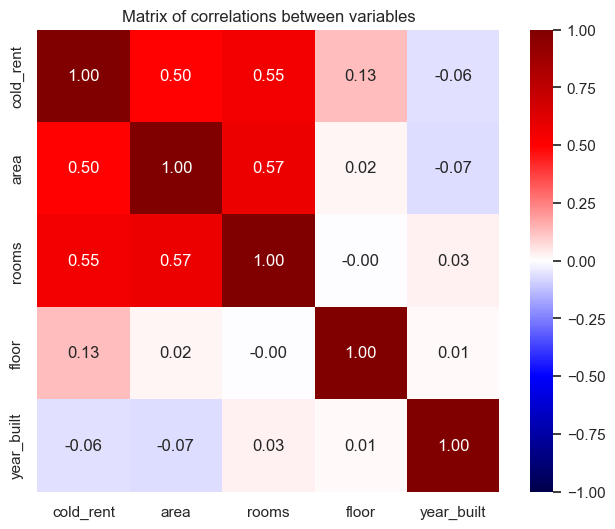

In [57]:
cols = df.select_dtypes(include=["float64"]).columns
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", square=True, cmap="seismic", vmin=-1, vmax=1)
plt.title("Matrix of correlations between variables")
plt.show() 

<span style="font-weight:500">
There is a clear strong correlation between area and cold rent, number of rooms and cold rent, and number of rooms and area, which are expected. There is a weak positive correlation between number of floors and cold rent, meaning higher floors might have slightly higher prices. That makes sense if we consider the floors that have most of the occurrences (0-5) and argue that higher floors like 2-5 have higher prices than the ground floor and the first floor, which is meaningful economically. 
<br>There is also a very weak negative correlation between year built and rent, meaning that old apartments tend to have slightly lower rent prices.
<br>There is also a weak negative correlation between area and year built, which can be associated with the fact that old apartments tend to have larger areas than new apartments.
<br> Matrix of correlation provided information that we could not grasp from some of the graphs.
</span>

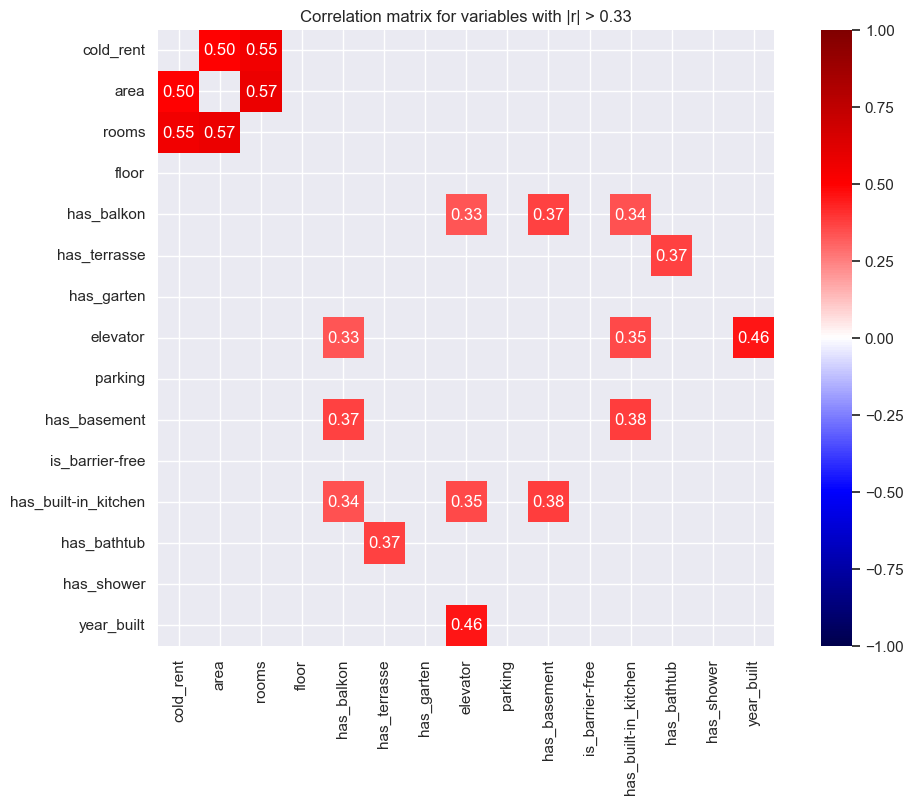

In [58]:
corr = df.drop(columns=["zip_code"]).corr(numeric_only=True)

# Mask where absolute correlation is below 0.33
mask = (np.abs(corr) < 0.33) | (np.abs(corr) == 1.00)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    cmap="seismic",
    vmin=-1,
    vmax=1,
    mask=mask
)

plt.title("Correlation matrix for variables with |r| > 0.33")
plt.show()

<span style="font-weight:500">
Since we have many features, let's keep track of the features with moderate to strong correlations.
<br>
All of the correlations are positive. For the cold rent, other than the features that we mentioned.
<br>
When it comes to independent features being correlated to each other, we have the following:
<ul>
  <li>Having a balcony is positively correlated with having an elevator, a basement and a built-in kitchen. </li>
  <li>Having a terrace is positively correlated with having a bathtub.</li>
  <li>Having an elevator is positively correlated with having a balcony, a built-in kitchen and the year when the apartment was built.</li>
  <li>Having a basement is positively correlated with having a balcony and built-in kitchen.</li>
</ul>
From these, the strongest correlation is the effect of the year when the apartment was built with having an elevator. This is very meaningful due to the fact that old buildings don't have elevators. 
</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 3: Saving the dataset</span>

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15588 entries, 0 to 15620
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   listing_url           15588 non-null  object 
 1   cold_rent             15588 non-null  float64
 2   area                  15588 non-null  float64
 3   rooms                 15588 non-null  float64
 4   floor                 13646 non-null  float64
 5   free_from             15588 non-null  object 
 6   has_balkon            15588 non-null  bool   
 7   has_terrasse          15588 non-null  bool   
 8   has_garten            15588 non-null  bool   
 9   elevator              15588 non-null  bool   
 10  parking               15588 non-null  bool   
 11  has_basement          15588 non-null  bool   
 12  is_barrier-free       15588 non-null  bool   
 13  has_built-in_kitchen  15588 non-null  bool   
 14  has_bathtub           15588 non-null  bool   
 15  has_shower            15

In [60]:
df.to_csv("../datasets/rent_listings_final.csv", encoding="utf-8-sig", index=False)